In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFECV, SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.model_selection import KFold, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
import pickle

In [2]:
df = pd.read_csv('Data/dataC.csv')

In [3]:
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,symptoms_count,symptoms_list,disease_diagnosis
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,...,147.3,152.88,97.5,102.5,188.9,108.3,97.4,0,NaN,Healthy
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,57.5,32.76,82.7,62.6,51.0,42.6,102.5,1,bone_pain,Rickets_Osteomalacia
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,152.1,94.99,169.3,136.2,116.6,136.3,86.4,2,dry_skin;night_blindness,Healthy
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,51.0,51.48,85.7,31.8,66.5,76.5,60.8,2,numbness_tingling;memory_problems,Anemia
4,63,Male,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,...,111.5,62.90,155.6,72.6,124.9,69.4,71.9,0,NaN,Healthy


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3500 non-null   int64  
 1   gender                   3500 non-null   object 
 2   bmi                      3500 non-null   float64
 3   smoking_status           3500 non-null   object 
 4   alcohol_consumption      2390 non-null   object 
 5   exercise_level           3500 non-null   object 
 6   diet_type                3500 non-null   object 
 7   sun_exposure             3500 non-null   object 
 8   income_level             3500 non-null   object 
 9   latitude_region          3500 non-null   object 
 10  vitamin_a_percent_rda    3500 non-null   float64
 11  vitamin_c_percent_rda    3500 non-null   float64
 12  vitamin_d_percent_rda    3500 non-null   float64
 13  vitamin_e_percent_rda    3500 non-null   float64
 14  vitamin_b12_percent_rda 

In [5]:
df.nunique()

age                          67
gender                        2
bmi                         248
smoking_status                3
alcohol_consumption           2
exercise_level                4
diet_type                     4
sun_exposure                  3
income_level                  3
latitude_region               3
vitamin_a_percent_rda      1311
vitamin_c_percent_rda      1314
vitamin_d_percent_rda      2116
vitamin_e_percent_rda      1327
vitamin_b12_percent_rda    1222
folate_percent_rda         1328
calcium_percent_rda        1281
iron_percent_rda           1200
symptoms_count                9
symptoms_list               228
disease_diagnosis             5
dtype: int64

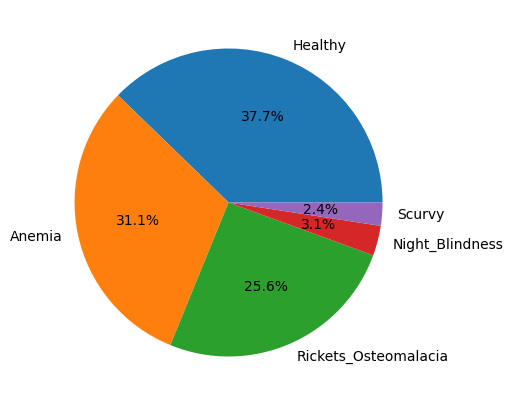

In [6]:
plt.figure(figsize=(8, 5))
plt.pie(df['disease_diagnosis'].value_counts(), labels=df['disease_diagnosis'].value_counts().index, autopct="%1.1f%%")
plt.show()

In [7]:
bmi_edges = [0, 18.5, 24.9, 29.9, 100] 
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

df['bmi_category'] = pd.cut(df['bmi'], bins=bmi_edges, labels=bmi_labels)

In [8]:
age_edges = [0, 30, 50, 120]
age_labels = ['Youth', 'Adults', 'Seniors']

df['age_group'] = pd.cut(df['age'], bins=age_edges, labels=age_labels)

In [9]:
df.drop(["age", "bmi"], axis=1, inplace=True)

In [10]:
df.isnull().sum()

gender                        0
smoking_status                0
alcohol_consumption        1110
exercise_level                0
diet_type                     0
sun_exposure                  0
income_level                  0
latitude_region               0
vitamin_a_percent_rda         0
vitamin_c_percent_rda         0
vitamin_d_percent_rda         0
vitamin_e_percent_rda         0
vitamin_b12_percent_rda       0
folate_percent_rda            0
calcium_percent_rda           0
iron_percent_rda              0
symptoms_count                0
symptoms_list              1152
disease_diagnosis             0
bmi_category                  0
age_group                     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
unique_symptoms = set()
for symptoms_str in df['symptoms_list'].dropna():
    unique_symptoms.update(s.strip() for s in symptoms_str.split(';'))

print(f'Number of unique symptoms: {len(unique_symptoms)}')
print(f'Symptoms: {unique_symptoms}')

df['symptoms_list'] = df['symptoms_list'].fillna('')

for symptom in unique_symptoms:
    df[symptom] = df['symptoms_list'].apply(
        lambda x: 1 if symptom in [s.strip() for s in x.split(';')] else 0
    )

df = df.drop('symptoms_list', axis=1)
df.head()

Number of unique symptoms: 9
Symptoms: {'night_blindness', 'muscle_weakness', 'bleeding_gums', 'bone_pain', 'pale_skin', 'dry_skin', 'numbness_tingling', 'memory_problems', 'fatigue'}


,gender,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,vitamin_a_percent_rda,vitamin_c_percent_rda,...,age_group,night_blindness,muscle_weakness,bleeding_gums,bone_pain,pale_skin,dry_skin,numbness_tingling,memory_problems,fatigue
0,Male,Former,NaN,Active,Vegetarian,High,High,Mid,119.1,147.3,...,Seniors,0,0,0,0,0,0,0,0,0
1,Female,Former,Moderate,Light,Omnivore,Low,Low,Low,85.7,57.5,...,Seniors,0,0,0,1,0,0,0,0,0
2,Male,Former,Heavy,Moderate,Omnivore,Low,High,High,48.3,152.1,...,Youth,1,0,0,0,0,1,0,0,0
3,Male,Never,Heavy,Moderate,Vegetarian,High,Low,Low,75.8,51.0,...,Seniors,0,0,0,0,0,0,1,1,0
4,Male,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,93.3,111.5,...,Seniors,0,0,0,0,0,0,0,0,0


In [13]:
df['alcohol_consumption'] = df['alcohol_consumption'].fillna("Missing").astype(str)

### Trying OneHotEncoder instead

In [14]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
nominal_features = ['gender', 'diet_type', 'smoking_status']
encoded_nominal = encoder.fit_transform(df[nominal_features])
nominal_df = pd.DataFrame(
    encoded_nominal, columns=encoder.get_feature_names_out(nominal_features)
)
df = pd.concat([df.drop(nominal_features, axis=1), nominal_df], axis=1)
df.head()

,alcohol_consumption,exercise_level,sun_exposure,income_level,latitude_region,vitamin_a_percent_rda,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,...,fatigue,gender_Female,gender_Male,diet_type_Omnivore,diet_type_Pescatarian,diet_type_Vegan,diet_type_Vegetarian,smoking_status_Current,smoking_status_Former,smoking_status_Never
0,Missing,Active,High,High,Mid,119.1,147.3,152.88,97.5,102.5,...,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,Moderate,Light,Low,Low,Low,85.7,57.5,32.76,82.7,62.6,...,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Heavy,Moderate,Low,High,High,48.3,152.1,94.99,169.3,136.2,...,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Heavy,Moderate,High,Low,Low,75.8,51.0,51.48,85.7,31.8,...,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,Missing,Moderate,Moderate,High,Low,93.3,111.5,62.90,155.6,72.6,...,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [15]:
ordinal_cols = ['alcohol_consumption', 'exercise_level', 'sun_exposure',
                'income_level', 'latitude_region', 'bmi_category', 'age_group']

ordinal_encoder_features = OrdinalEncoder(
    categories=[
        ['Missing', 'Moderate', 'Heavy'],               # alcohol_consumption
        ['Sedentary', 'Light', 'Moderate', 'Active'],   # exercise_level
        ['Low', 'Moderate', 'High'],                    # sun_exposure
        ['Low', 'Middle', 'High'],                      # income_level
        ['Low', 'Mid', 'High'],                         # latitude_region
        ['Underweight', 'Normal', 'Overweight', 'Obese'], # bmi_category
        ['Youth', 'Adults', 'Seniors'],                 # age_group
    ],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

df[ordinal_cols] = ordinal_encoder_features.fit_transform(df[ordinal_cols])

In [16]:
ordinal_encoder_target = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
df['disease_diagnosis'] = ordinal_encoder_target.fit_transform(df[['disease_diagnosis']])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   alcohol_consumption      3500 non-null   float64
 1   exercise_level           3500 non-null   float64
 2   sun_exposure             3500 non-null   float64
 3   income_level             3500 non-null   float64
 4   latitude_region          3500 non-null   float64
 5   vitamin_a_percent_rda    3500 non-null   float64
 6   vitamin_c_percent_rda    3500 non-null   float64
 7   vitamin_d_percent_rda    3500 non-null   float64
 8   vitamin_e_percent_rda    3500 non-null   float64
 9   vitamin_b12_percent_rda  3500 non-null   float64
 10  folate_percent_rda       3500 non-null   float64
 11  calcium_percent_rda      3500 non-null   float64
 12  iron_percent_rda         3500 non-null   float64
 13  symptoms_count           3500 non-null   int64  
 14  disease_diagnosis       

In [18]:
numerical_features = ['symptoms_count', 'iron_percent_rda', 'calcium_percent_rda', 'folate_percent_rda',
                      'vitamin_b12_percent_rda', 'vitamin_e_percent_rda', 'vitamin_d_percent_rda',
                      'vitamin_c_percent_rda', 'vitamin_a_percent_rda']

In [19]:
df[numerical_features].skew()

symptoms_count             0.713992
iron_percent_rda           0.742192
calcium_percent_rda        0.674578
folate_percent_rda         0.567024
vitamin_b12_percent_rda    0.895606
vitamin_e_percent_rda      0.586428
vitamin_d_percent_rda      1.281222
vitamin_c_percent_rda      0.609679
vitamin_a_percent_rda      0.545463
dtype: float64

In [20]:
def detect_outliers_iqr(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_indices = np.where((data < lower_bound) | (data > upper_bound))
    outlier_values = data[outlier_indices]
    print(f'Lower Bound: {lower_bound}, Upper Bound: {upper_bound}')
    return outlier_indices[0], outlier_values

In [21]:
for feature in numerical_features:
    indices, values = detect_outliers_iqr(df[feature].values)
    print(f'The IQR outliers of {feature}')
    for idx, val in zip(indices, values):
        print(f'Index: {idx}, Value: {val}')

Lower Bound: -4.5, Upper Bound: 7.5
The IQR outliers of symptoms_count
Index: 380, Value: 8
Index: 584, Value: 8
Index: 607, Value: 8
Index: 1764, Value: 8
Index: 2504, Value: 8
Index: 2874, Value: 8
Index: 3221, Value: 8
Lower Bound: -14.562500000000007, Upper Bound: 162.3375
The IQR outliers of iron_percent_rda
Index: 128, Value: 180.3
Index: 287, Value: 168.1
Index: 294, Value: 172.5
Index: 314, Value: 167.1
Index: 329, Value: 168.7
Index: 338, Value: 183.1
Index: 350, Value: 181.0
Index: 452, Value: 172.3
Index: 458, Value: 175.8
Index: 474, Value: 211.4
Index: 603, Value: 169.0
Index: 618, Value: 175.1
Index: 673, Value: 202.1
Index: 880, Value: 163.1
Index: 888, Value: 182.3
Index: 902, Value: 173.9
Index: 1017, Value: 165.9
Index: 1112, Value: 166.8
Index: 1349, Value: 163.8
Index: 1457, Value: 162.5
Index: 1489, Value: 179.7
Index: 1670, Value: 174.1
Index: 1781, Value: 162.6
Index: 1965, Value: 182.9
Index: 1972, Value: 180.7
Index: 2092, Value: 182.1
Index: 2097, Value: 163.6

### Train/Test Split

In [22]:
y = df['disease_diagnosis']
x = df.drop(columns=['disease_diagnosis'])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [23]:
# Scaling ....
scaler = RobustScaler() # 
x_train[numerical_features] = scaler.fit_transform(x_train[numerical_features])
x_test[numerical_features] = scaler.fit_transform(x_test[numerical_features])

### Feature Selection

In [24]:
# Variance Threshold
variance_selector = VarianceThreshold(threshold=0.01)
x_selected = variance_selector.fit_transform(x_train)
x_test_selected = variance_selector.transform(x_test)

# Get features that passed variance threshold
variance_kept_features = x_train.columns[variance_selector.get_support()].tolist()
print(f'After Variance Threshold: {len(variance_kept_features)}\n{variance_kept_features}')

# Mutual Information (on the variance-filtered data)
information_selector = SelectKBest(score_func=mutual_info_classif, k=20)
x_selected = information_selector.fit_transform(x_selected, y_train)
x_test_selected = information_selector.transform(x_test_selected)

# Get features that passed BOTH filters
# Index into variance_kept_features, not x_train.columns
final_kept_features = [variance_kept_features[i] for i, supported in enumerate(information_selector.get_support()) if supported]
print(f'After Mutual Information: {len(final_kept_features)}\n{final_kept_features}')


After Variance Threshold: 34
['alcohol_consumption', 'exercise_level', 'sun_exposure', 'income_level', 'latitude_region', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda', 'symptoms_count', 'bmi_category', 'age_group', 'night_blindness', 'muscle_weakness', 'bleeding_gums', 'bone_pain', 'pale_skin', 'dry_skin', 'numbness_tingling', 'memory_problems', 'fatigue', 'gender_Female', 'gender_Male', 'diet_type_Omnivore', 'diet_type_Pescatarian', 'diet_type_Vegan', 'diet_type_Vegetarian', 'smoking_status_Current', 'smoking_status_Former', 'smoking_status_Never']
After Mutual Information: 20
['sun_exposure', 'income_level', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda', 'symptoms_count', 'night_blindness', 'muscle

In [25]:
# Wrapper
estimator = RandomForestClassifier(n_estimators=100, n_jobs=-1)
selector = RFECV(estimator, cv=5)
selector = selector.fit(x_selected, y_train)

# Print the optimal number of features
print("Optimal number of features: %d" % selector.n_features_)

# Print the selected features
print("Selected features: %s" % selector.support_)

Optimal number of features: 9
Selected features: [ True False  True  True  True False  True  True False  True  True False
 False False False  True False False False False]


In [26]:
x_selected = pd.DataFrame(x_selected, columns=x_train.columns[information_selector.get_support()])
selected_features = x_selected.columns[selector.support_].tolist()
print(selected_features)

['sun_exposure', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda', 'iron_percent_rda', 'symptoms_count', 'numbness_tingling']


In [27]:
x_train_selected = selector.transform(x_selected)
x_test_selected = selector.transform(x_test_selected)

c:\Users\rinad\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RFECV was fitted without feature names
  warnings.warn(


In [28]:
def fit_classification_models(x_train, y_train_c):
    # 1. Define the Models
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42),
        "XGB": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        "SVC": SVC(probability=True)
    }

    # 2. Define the Hyperparameter Grids
    param_grids = {
        "Logistic Regression": {
            'C': [0.1, 1, 10],
            'solver': ['lbfgs', 'liblinear']
        },
        "Random Forest": {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        },
        "XGB": {
            'n_estimators': [100, 400],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 6]
        },
        "SVC": {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        }
    }
    return models, param_grids


In [29]:
def run_clas_models_train(x_train, y_train_c):
    best_models = {}
    results = []
    models, param_grids = fit_classification_models(x_train, y_train_c)
    for name, model in models.items():
        print(f"Searching for best parameters: {name}...")

        grid_search = GridSearchCV( estimator=model, param_grid=param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)

        grid_search.fit(x_train, y_train_c)

        best_models[name] = grid_search.best_estimator_
        results.append({
            "Model": name,
            "Best Score": grid_search.best_score_,
            "Best Params": grid_search.best_params_
        })

    return best_models, pd.DataFrame(results)

In [30]:
best_class , data_frame = run_clas_models_train(x_train, y_train)

Searching for best parameters: Logistic Regression...
Searching for best parameters: Random Forest...
Searching for best parameters: XGB...


c:\Users\rinad\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:50:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Searching for best parameters: SVC...


In [31]:
data_frame

,Model,Best Score,Best Params
0,Logistic Regression,0.917857,"{'C': 10, 'solver': 'lbfgs'}"
1,Random Forest,0.980357,"{'max_depth': None, 'min_samples_split': 2, 'n..."
2,XGB,0.996786,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
3,SVC,0.911786,"{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}"


In [32]:
def fit_classification_models_req():

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),

        "Random Forest": RandomForestClassifier(
            random_state=42
        ),

        "XGB": XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        ),

        "SVC": SVC(probability=True)
    }

    # One hyperparameter varied at a time
    param_grids = {

        "Logistic Regression": [
            {
                'C': [0.01, 0.1, 1]
            },
            {
                'solver': ['lbfgs', 'liblinear', 'saga']
            }
        ],

        "Random Forest": [
            {
                'n_estimators': [50, 100, 200]
            },
            {
                'max_depth': [5, 10, 20]
            },
            {
                'min_samples_split': [2, 5, 10]
            }
        ],

        "XGB": [
            {
                'n_estimators': [100, 200, 400]
            },
            {
                'learning_rate': [0.001, 0.01, 0.1]
            },
            {
                'max_depth': [3, 6, 9]
            }
        ],

        "SVC": [
            {
                'C': [0.1, 1, 10]
            },
            {
                'kernel': ['linear', 'rbf', 'poly']
            },
            {
                'gamma': ['scale', 'auto', 0.1]
            }
        ]
    }

    return models, param_grids

In [33]:
import pandas as pd
import time
from sklearn.model_selection import GridSearchCV

def run_clas_models_train_req(x_train, y_train_c):

    best_models = {}
    results = []

    models, param_grids = fit_classification_models_req()

    for model_name, model in models.items():

        print(f"\n===== {model_name} =====")

        best_score_overall = 0
        best_estimator_overall = None

        for grid in param_grids[model_name]:

            hyperparameter_name = list(grid.keys())[0]

            print(f"\nTuning: {hyperparameter_name}")

            grid_search = GridSearchCV(
                estimator=model,
                param_grid=grid,
                cv=5,
                scoring='accuracy',
                n_jobs=-1
            )

            # -------------------------
            # TRAINING TIME
            # -------------------------
            start_train = time.time()

            grid_search.fit(x_train, y_train_c)

            end_train = time.time()

            train_time = end_train - start_train

            # -------------------------
            # RESULTS
            # -------------------------
            print("Best Score:", grid_search.best_score_)
            print("Best Params:", grid_search.best_params_)

            results.append({
                "Model": model_name,
                "Hyperparameter": hyperparameter_name,
                "Best Score": grid_search.best_score_,
                "Best Params": grid_search.best_params_,
                "Training Time": train_time
            })

            # Keep best model
            if grid_search.best_score_ > best_score_overall:
                best_score_overall = grid_search.best_score_
                best_estimator_overall = grid_search.best_estimator_

        best_models[model_name] = best_estimator_overall

    return best_models, pd.DataFrame(results)

In [34]:
best_class_2 , data_frame_2 = run_clas_models_train_req(x_train_selected, y_train)


===== Logistic Regression =====

Tuning: C
Best Score: 0.8785714285714284
Best Params: {'C': 1}

Tuning: solver
Best Score: 0.8789285714285713
Best Params: {'solver': 'saga'}

===== Random Forest =====

Tuning: n_estimators
Best Score: 0.9942857142857143
Best Params: {'n_estimators': 100}

Tuning: max_depth
Best Score: 0.9942857142857143
Best Params: {'max_depth': 20}

Tuning: min_samples_split
Best Score: 0.9953571428571429
Best Params: {'min_samples_split': 5}

===== XGB =====

Tuning: n_estimators


c:\Users\rinad\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:50:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Score: 0.9964285714285716
Best Params: {'n_estimators': 100}

Tuning: learning_rate


c:\Users\rinad\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:50:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Score: 0.9960714285714285
Best Params: {'learning_rate': 0.1}

Tuning: max_depth


c:\Users\rinad\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:50:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Score: 0.9964285714285716
Best Params: {'max_depth': 3}

===== SVC =====

Tuning: C
Best Score: 0.9332142857142858
Best Params: {'C': 10}

Tuning: kernel
Best Score: 0.9039285714285714
Best Params: {'kernel': 'rbf'}

Tuning: gamma
Best Score: 0.9039285714285714
Best Params: {'gamma': 'scale'}


In [35]:
data_frame_2

,Model,Hyperparameter,Best Score,Best Params,Training Time
0,Logistic Regression,C,0.878571,{'C': 1},0.297601
1,Logistic Regression,solver,0.878929,{'solver': 'saga'},0.427605
2,Random Forest,n_estimators,0.994286,{'n_estimators': 100},4.755061
3,Random Forest,max_depth,0.994286,{'max_depth': 20},4.110172
4,Random Forest,min_samples_split,0.995357,{'min_samples_split': 5},3.517813
5,XGB,n_estimators,0.996429,{'n_estimators': 100},2.698732
6,XGB,learning_rate,0.996071,{'learning_rate': 0.1},4.606030
7,XGB,max_depth,0.996429,{'max_depth': 3},1.669094
8,SVC,C,0.933214,{'C': 10},4.939419
9,SVC,kernel,0.903929,{'kernel': 'rbf'},181.341294


In [37]:
import pandas as pd
import time
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

def test_classification_models(best_models, X_test, y_test):

    test_results = []

    for name, model in best_models.items():

        
        start_test = time.time()
        y_pred = model.predict(X_test)
        end_test = time.time()

        test_time = end_test - start_test

       
        acc = accuracy_score(y_test, y_pred)

        try:
            y_proba = model.predict_proba(X_test)

            if len(y_proba.shape) > 1 and y_proba.shape[1] == 2:
                auc = roc_auc_score(y_test, y_proba[:, 1])
            else:
                auc = "N/A (Multi-class)"

        except:
            auc = "N/A"

        # -------------------------
        # Store Results
        # -------------------------
        test_results.append({
            "Model": name,
            "Test Accuracy": acc,
            "ROC-AUC": auc,
            "Test Time": test_time
        })

        print(f"Model: {name}")
        print(f"Accuracy: {acc:.4f}")
        print(f"Test Time: {test_time:.4f} sec")
        print(classification_report(y_test, y_pred))
        print("-" * 30)

    results_df = pd.DataFrame(test_results).sort_values(
        by="Test Accuracy",
        ascending=False
    )

    return results_df


final_report = test_classification_models(
    best_class_2,
    x_test_selected,
    y_test
)

print(final_report)

Model: Logistic Regression
Accuracy: 0.8757
Test Time: 0.0010 sec
              precision    recall  f1-score   support

         0.0       0.89      0.79      0.84       218
         1.0       0.89      0.94      0.91       264
         2.0       0.80      0.73      0.76        22
         3.0       0.86      0.94      0.90       179
         4.0       0.57      0.47      0.52        17

    accuracy                           0.88       700
   macro avg       0.80      0.77      0.79       700
weighted avg       0.87      0.88      0.87       700

------------------------------
Model: Random Forest
Accuracy: 0.9729
Test Time: 0.0664 sec
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97       218
         1.0       1.00      0.97      0.98       264
         2.0       0.76      1.00      0.86        22
         3.0       0.99      0.98      0.99       179
         4.0       0.84      0.94      0.89        17

    accuracy                

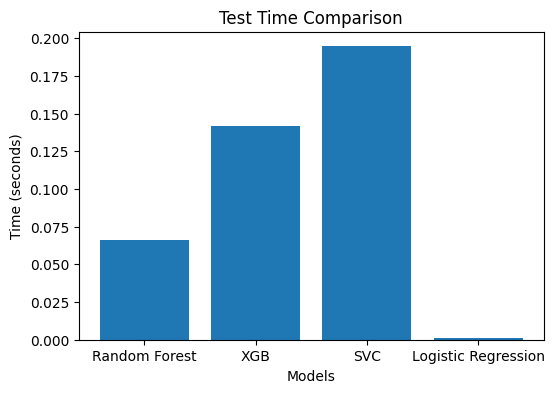

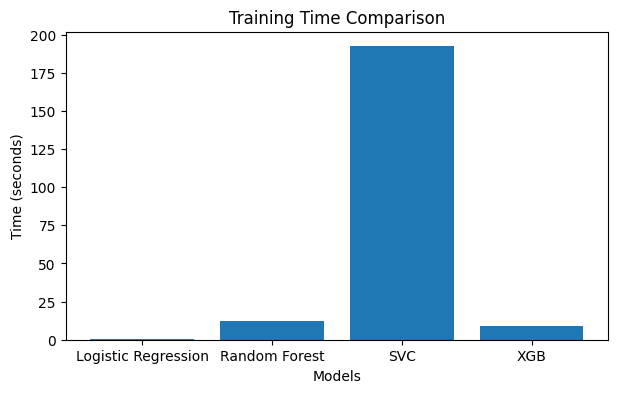

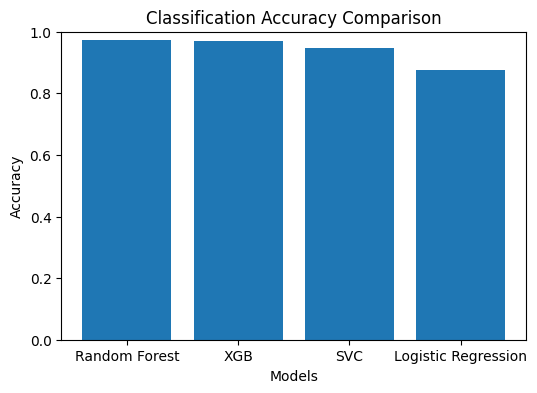

In [42]:
# Test time bar graph
plt.figure(figsize=(6,4))

plt.bar(final_report["Model"], final_report["Test Time"])

plt.title("Test Time Comparison")
plt.xlabel("Models")
plt.ylabel("Time (seconds)")

plt.show()

# Train time bar graph

train_time_df = data_frame_2.groupby("Model")["Training Time"].sum()

plt.figure(figsize=(7,4))

plt.bar(train_time_df.index, train_time_df.values)

plt.title("Training Time Comparison")
plt.xlabel("Models")
plt.ylabel("Time (seconds)")

plt.show()

#acc
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    final_report["Model"],
    final_report["Test Accuracy"]
)

plt.title("Classification Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0, 1)  # optional: keeps scale clean

plt.show()

In [39]:
#Save Encoding, Scaling, Models
#Preprocessing -> binning - sysmptoms encoding - 
#Feature Selected
pickle.dump(best_class_2['Logistic Regression'], 'lr.pkl')
pickle.dump(best_class_2['Random Forest'], 'rf.pkl')
pickle.dump(best_class_2['SVC'], 'svc.pkl')
pickle.dump(best_class_2['XGB'], 'xgb.pkl')
pickle.dump(encoder, 'nominal_encoder.pkl')
pickle.dump(ordinal_encoder_features, 'ordinal_encoder.pkl')
pickle.dump(ordinal_encoder_target, 'target_encoder.pkl')
pickle.dump(scaler, 'scaler.pkl')
num_cols = ['vitamin_b12_percent_rda', 'iron_percent_rda', 'symptoms_count', 'vitamin_d_percent_rda']
pickle.dump(df[num_cols].median(), open('medians.pkl', 'wb'))

TypeError: file must have a 'write' attribute